# German Electricity Demand Forecasting — Colab runner

This notebook clones/uploads the `electricity-demand-forecasting` repository, installs dependencies, builds the processed dataset, and runs the full modelling pipeline (benchmarks, SARIMAX, SARIMAX+exogenous, feature-based model, and optionally Bayesian/LSTM models).

**Two ways to get the code into Colab:**
1. Push the repo to GitHub, then `git clone` it here (recommended), or
2. Upload the project zip directly to this Colab session and unzip it.

Both options are set up below — just run the cell that matches what you're doing.

## 0. Get the repository into this Colab session

In [ ]:
# OPTION A: clone from GitHub (recommended once you've pushed the repo)
# Replace the URL with your own repository.

# !git clone https://github.com/<your-username>/electricity-demand-forecasting.git
# %cd electricity-demand-forecasting


In [2]:
# OPTION B: upload the project zip you were given, and unzip it here.
from google.colab import files
import zipfile, os

uploaded = files.upload()  # choose electricity-demand-forecasting.zip in the dialog

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')

os.chdir('electricity-demand-forecasting')
print('Working directory:', os.getcwd())


Saving electricity-demand-forecasting.zip to electricity-demand-forecasting (1).zip
Working directory: /content/electricity-demand-forecasting


## 1. Install dependencies

In [3]:
!pip install -q -r requirements.txt
!pip install -q -e .   # installs the electricity_demand package in editable mode


  Preparing metadata (setup.py) ... done


## 2. Get the raw data

If you already have `time_series_60min_singleindex.csv` in `data/raw/` (e.g. because it was bundled in the zip you uploaded), you can skip straight to step 3. Otherwise, download it fresh from Open Power System Data.

In [4]:
import os
from pathlib import Path

raw_path = Path('data/raw/time_series_60min_singleindex.csv')
print('Already present:', raw_path.exists())

if not raw_path.exists():
    !python scripts/download_data.py


Already present: True


## 3. Build the processed weekly modelling table

This cleans and aggregates the hourly load data, fetches Berlin temperature from Open-Meteo, and assembles the full weekly feature table (calendar, holiday, temperature, lag, and rolling features).

In [7]:
patch = '''
    df = df.set_index("timestamp").sort_index()
    df.index = df.index.tz_localize(None)
    return df
'''
import re
path = 'src/electricity_demand/data.py'
with open(path) as f:
    content = f.read()
content = content.replace(
    '    df = df.set_index("timestamp").sort_index()\n\n    return df',
    '    df = df.set_index("timestamp").sort_index()\n    df.index = df.index.tz_localize(None)\n\n    return df'
)
with open(path, 'w') as f:
    f.write(content)
print("patched")

patched


In [8]:
!python scripts/make_features.py

Building interim hourly/daily/weekly datasets...
  weekly series: 2015-01-11 to 2020-09-27, 299 weeks
Fetching Berlin daily temperature from Open-Meteo...
  retrieved 2100 days of temperature data
Assembling weekly modelling table...
Saved processed modelling table to /content/electricity-demand-forecasting/data/processed/modelling_table_weekly.csv
  shape: (247, 25)
  columns: ['load_gw', 'year', 'week_of_year', 'month', 'trend', 'week_sin', 'week_cos', 'holiday_days', 'has_holiday', 'temp_mean', 'temp_min', 'temp_max', 'heating_degree_days', 'cooling_degree_days', 'load_lag_1', 'load_lag_2', 'load_lag_3', 'load_lag_4', 'load_lag_52', 'load_roll_mean_4', 'load_roll_std_4', 'load_roll_mean_8', 'load_roll_std_8', 'load_roll_mean_52', 'load_roll_std_52']


## 4. Quick look at the processed data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

table = pd.read_csv('data/processed/modelling_table_weekly.csv', index_col=0, parse_dates=True)
print(table.shape)
table.head()


(247, 25)


,load_gw,year,week_of_year,month,trend,week_sin,week_cos,holiday_days,has_holiday,temp_mean,...,load_lag_2,load_lag_3,load_lag_4,load_lag_52,load_roll_mean_4,load_roll_std_4,load_roll_mean_8,load_roll_std_8,load_roll_mean_52,load_roll_std_52
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-10,56.615143,2016,1,1,52,0.120537,0.992709,0,0,-3.314286,...,48.253363,57.627857,59.907333,56.191101,53.288147,6.405489,56.483165,5.445156,54.744419,3.165634
2016-01-17,59.913911,2016,2,1,53,0.239316,0.970942,0,0,0.257143,...,47.364036,48.253363,57.627857,57.672679,52.465100,5.404828,56.248656,5.386401,54.752573,3.169977
2016-01-24,61.267530,2016,3,1,54,0.354605,0.935016,0,0,-3.642857,...,56.615143,47.364036,48.253363,58.613304,53.036613,6.195717,56.315124,5.433666,54.795674,3.225214
2016-01-31,59.185089,2016,4,1,55,0.464723,0.885456,0,0,6.357143,...,59.913911,56.615143,47.364036,58.734030,56.290155,6.263308,56.381981,5.498687,54.846717,3.306788
2016-02-07,59.329810,2016,5,2,56,0.568065,0.822984,0,0,5.700000,...,61.267530,59.913911,56.615143,59.323899,59.245418,1.954295,56.266783,5.418577,54.855391,3.317759


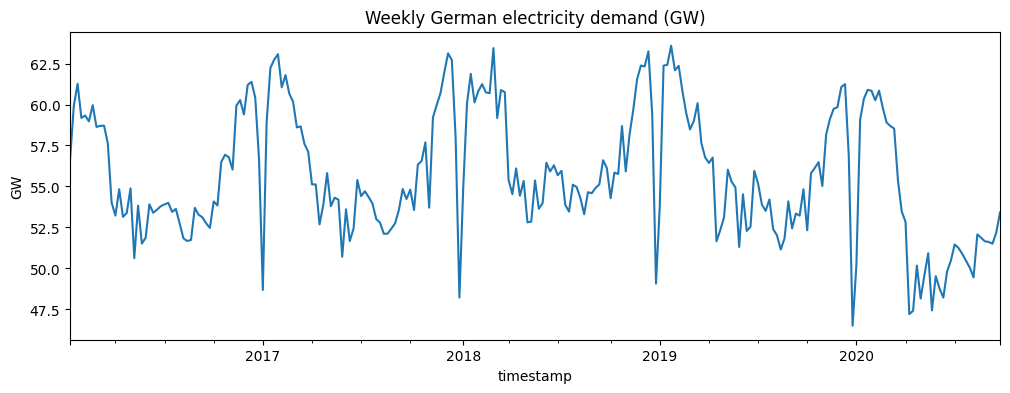

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
table['load_gw'].plot(ax=ax)
ax.set_title('Weekly German electricity demand (GW)')
ax.set_ylabel('GW')
plt.show()


## 5. Stationarity checks (ADF, ACF, PACF)

Required by Part 1 of the assignment: test whether the weekly series is stationary, and inspect its autocorrelation structure before choosing SARIMA orders.

ADF statistic: -3.503808300898959
p-value: 0.00788982579462222
Critical values: {'1%': np.float64(-3.458128284586202), '5%': np.float64(-2.873761835239286), '10%': np.float64(-2.5732834559706235)}


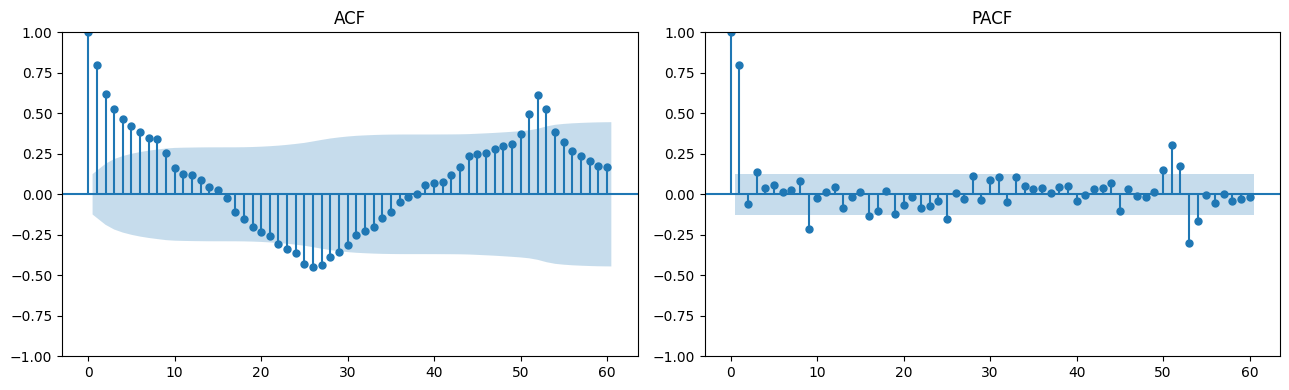

In [11]:
from statsmodels.tsa.stattools import adfuller
from electricity_demand.plotting import plot_acf_pacf

y = table['load_gw']

adf_result = adfuller(y)
print('ADF statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical values:', adf_result[4])

fig = plot_acf_pacf(y, lags=60)
plt.show()


In [12]:
# The series is very likely non-stationary in level (trend + strong annual seasonality).
# Inspect the first seasonal difference as well:
y_diff52 = y.diff(52).dropna()
adf_diff = adfuller(y_diff52)
print('ADF statistic (seasonal diff):', adf_diff[0])
print('p-value (seasonal diff):', adf_diff[1])


ADF statistic (seasonal diff): -1.7722710852365227
p-value (seasonal diff): 0.3943126078615381


## 6. (Optional) SARIMA order search by AIC

The assignment asks for a brute-force grid search over p in [0,6], d in [0,2], q in [0,6] with the seasonal order fixed. **This is slow** (up to 147 SARIMAX fits on a 52-period seasonal model) — expect this cell to take a long time on Colab CPU. Reduce the ranges below for a quicker demonstration if you just want to check the pipeline runs; use the full ranges for your final submitted results.

In [14]:
from electricity_demand.models.sarimax import grid_search_sarima

test_weeks = 104
y_train_full = y.iloc[:-test_weeks]

# Full assignment-required search (slow):
# results = grid_search_sarima(y_train_full, p_range=range(0,7), d_range=range(0,3), q_range=range(0,7))

# Faster demo search:
results = grid_search_sarima(y_train_full, p_range=range(0,3), d_range=range(0,2), q_range=range(0,3))
results.head(10)


,p,d,q,aic
0,2,0,2,131.550176
1,0,0,2,133.758600
2,1,0,2,135.275800
3,2,1,0,141.369603
4,0,0,1,141.737296
5,2,1,2,141.843318
6,2,1,1,142.830873
7,1,0,1,143.619972
8,2,0,0,143.707521
9,0,1,2,144.541503


## 7. Run the full forecasting pipeline

This fits benchmarks, SARIMAX (with temperature + holiday exogenous regressors), and the gradient-boosting feature model; evaluates all of them on the same 104-week test period; and saves forecasts, metrics, and figures under `outputs/`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


,model,MAE,RMSE,MASE,Bias
5,feature_model,2.223,2.976,1.603,1.600
2,seasonal_naive,2.288,2.988,1.650,1.748
3,drift,3.785,4.387,2.729,0.803
0,mean,3.842,4.460,2.771,0.909
1,naive,3.858,4.476,2.782,0.985
4,sarimax,4.455,5.386,3.212,4.437


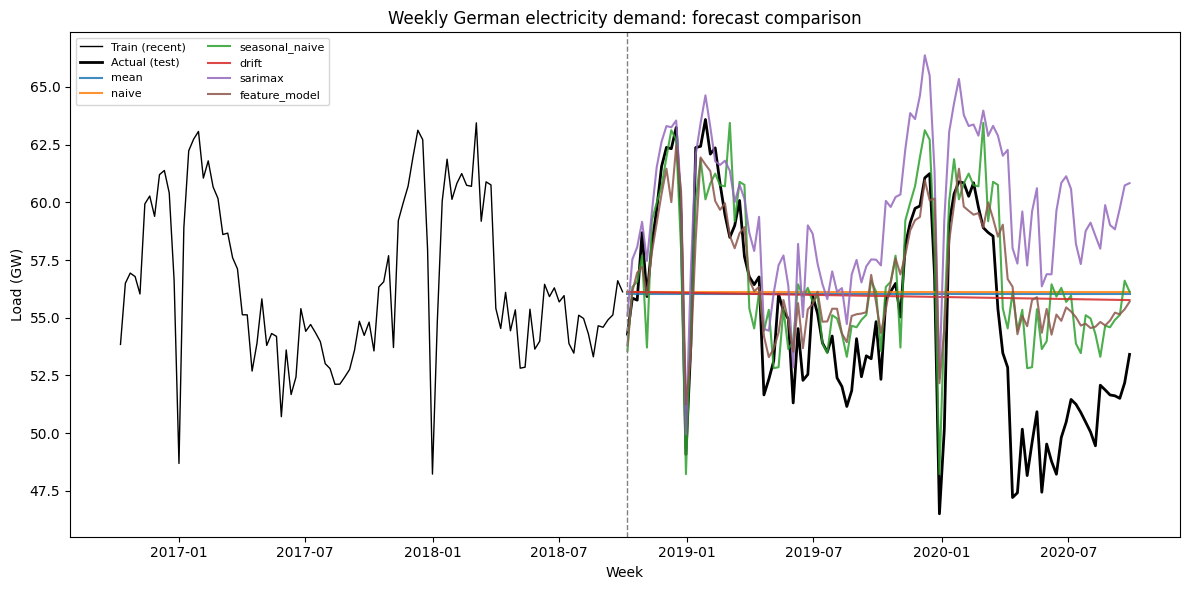

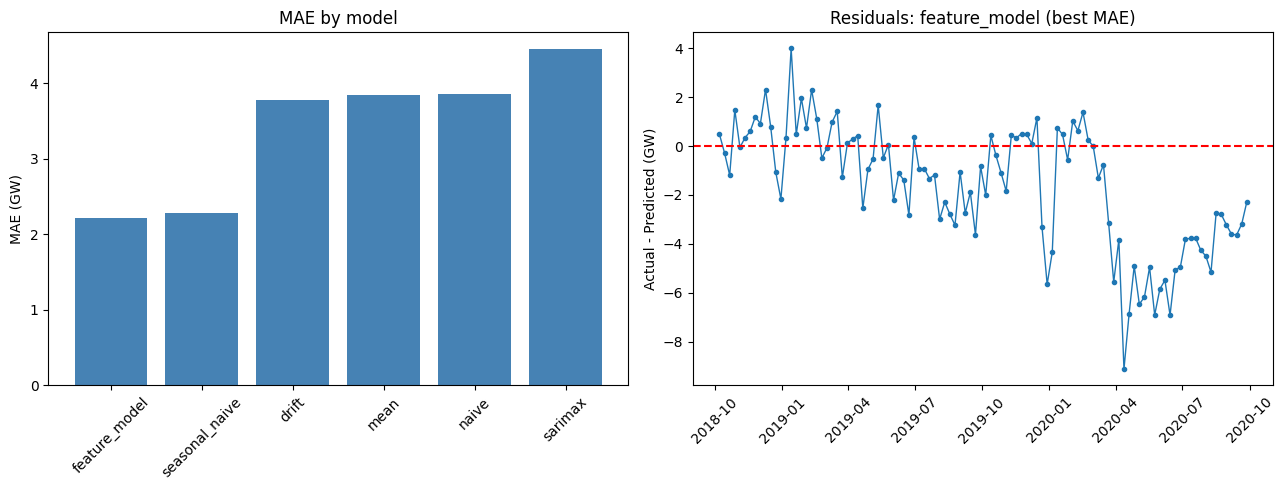

In [15]:
from electricity_demand.pipeline import run_pipeline

metrics_df, forecast_df = run_pipeline(
    include_sarimax=True,
    include_feature_model=True,
    include_bayesian=False,
    include_neural=False,
)

metrics_df.round(3)


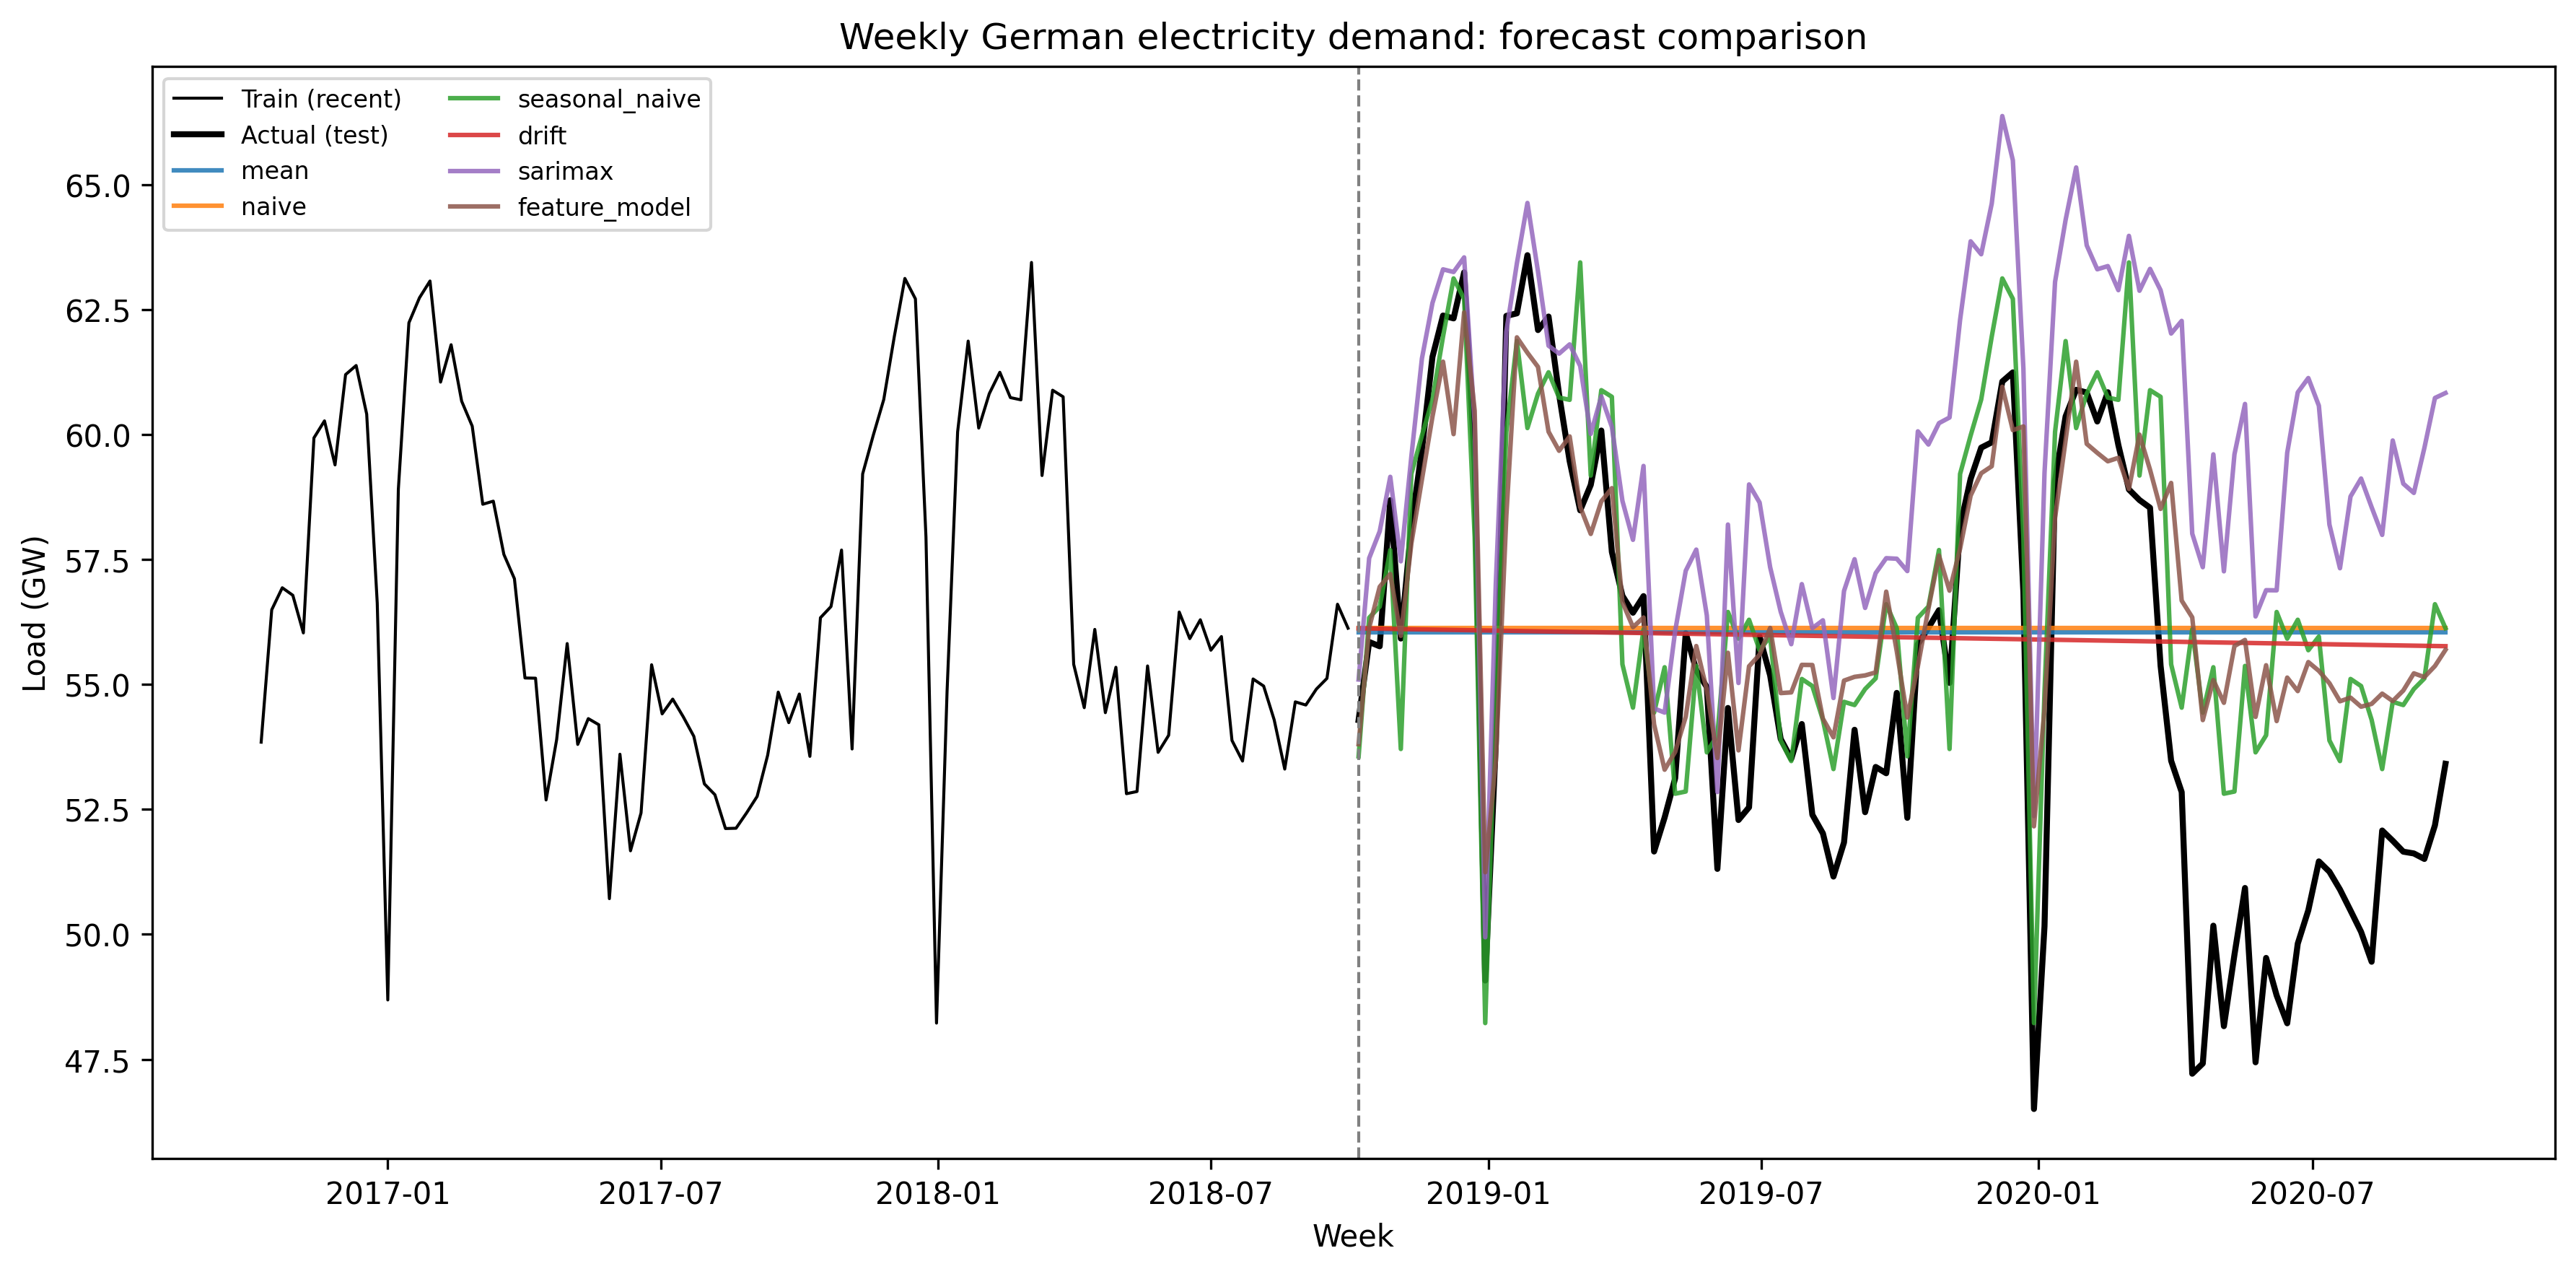

In [16]:
from IPython.display import Image
Image('outputs/figures/forecast_comparison.png')


## 8. (Optional) Bayesian model

Re-run the pipeline with `include_bayesian=True` to add a Bayesian ridge regression forecast and compare it against the others.

In [ ]:
metrics_df_bayes, forecast_df_bayes = run_pipeline(
    include_sarimax=True,
    include_feature_model=True,
    include_bayesian=True,
    include_neural=False,
)
metrics_df_bayes.round(3)


## 9. (Optional) LSTM model on hourly data

Part 6 of the assignment. This trains an LSTM on the hourly load series and recursively forecasts the 2-year test horizon, then aggregates to weekly for comparison. **This is the slowest step** — use a GPU runtime (`Runtime > Change runtime type > GPU`) if available.

In [ ]:
metrics_df_full, forecast_df_full = run_pipeline(
    include_sarimax=True,
    include_feature_model=True,
    include_bayesian=True,
    include_neural=True,
)
metrics_df_full.round(3)


## 10. Run the test suite

Sanity-checks the core functions (forecast lengths, MASE=0 for a perfect forecast, no lag leakage, no missing target values).

In [17]:
!python -m pytest tests/ -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/electricity-demand-forecasting
plugins: anyio-4.14.0, typeguard-4.5.2, langsmith-0.9.1
collected 12 items                                                             

tests/test_benchmarks.py::test_forecast_length_matches_horizon PASSED    [  8%]
tests/test_benchmarks.py::test_naive_forecast_equals_last_value PASSED   [ 16%]
tests/test_benchmarks.py::test_seasonal_naive_repeats_last_season PASSED [ 25%]
tests/test_evaluation.py::test_mase_zero_for_perfect_forecast PASSED     [ 33%]
tests/test_evaluation.py::test_mae_and_rmse_zero_for_perfect_forecast PASSED [ 41%]
tests/test_evaluation.py::test_bias_sign PASSED                          [ 50%]
tests/test_evaluation.py::test_evaluate_forecast_returns_expected_keys PASSED [ 58%]
tests/test_features.py::test_lag_features_do_not_use_future

## 11. Download outputs

Zip up the generated outputs (forecasts, metrics, figures) to download locally or attach to your report.

In [18]:
import shutil
shutil.make_archive('outputs_bundle', 'zip', 'outputs')

from google.colab import files
files.download('outputs_bundle.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>